# 🇰🇪 Kenya Consumer Price Index (CPI) & Inflation Analysis
## March 2025 – March 2026
### Analyst: Felix Beru Tsinzole | Financial & Data Analyst | Nairobi, Kenya

---

## Project Overview

This notebook presents a comprehensive analysis of Kenya's Consumer Price
Index (CPI) and inflation trends for the period March 2025 to March 2026,
using data published by the Kenya National Bureau of Statistics (KNBS).

The analysis is structured as a professional financial research report
moving from raw data through cleaning, analysis and visualization to
actionable business insights.

## Why This Analysis Matters

Inflation is not just a macroeconomic statistic. For businesses operating
in Kenya  particularly those serving rural households  inflation directly
affects:

- **Consumer purchasing power** — can households afford products and services?
- **Input costs** — are operating costs rising faster than revenues?
- **Loan repayment ability** — for companies with loan-to-own models,
  rising food costs reduce disposable income available for repayments
- **Pricing strategy** — when should prices be adjusted, and by how much?

## Data Sources

| Dataset | Source | Coverage |
|---|---|---|
| CPI by Division | KNBS CPI Report March 2026 | 13 COICOP Divisions |
| Commodity Prices | KNBS CPI Report March 2026 | 17 Key Commodities |
| Core vs Non-Core | KNBS CPI Report March 2026 | Mar 2025 – Mar 2026 |

## Structure of This Analysis

1. **Data Loading & Validation** — confirming data integrity
2. **Data Cleaning** — standardizing formats and checking for errors
3. **Inflation by Division** — which sectors are driving inflation
4. **Commodity Price Movement** — which products are most affected
5. **Core vs Non-Core Trends** — understanding structural vs volatile inflation
6. **Executive Summary** — key findings and business implications

## Section 1 — Data Loading & Validation

### What We Are Loading

We are loading three separate datasets from the KNBS CPI March 2026 report:

1. **CPI by Division** — 13 COICOP (Classification of Individual Consumption
   by Purpose) divisions showing annual and monthly inflation rates.
   Each division has a weight reflecting its share of household expenditure.

2. **Commodity Prices** — 17 key commodities showing average retail prices
   in March 2025, February 2026 and March 2026, with monthly and annual
   percentage changes.

3. **Core vs Non-Core Index** — monthly index values and inflation rates
   for core (stable) and non-core (volatile) components over 13 months.

### Why We Validate on Load

In financial analysis, data integrity is non-negotiable.
Before building any charts or drawing any conclusions we must confirm:
- All rows loaded correctly
- Column names are clean and consistent
- No unexpected null values or data types
- Row and column counts match what we expect from the source report

A financial report built on dirty data is worse than no report at all.

In [3]:
# ================================================
# SECTION 1 — DATA LOADING & VALIDATION
# Kenya CPI & Inflation Analysis
# Analyst: Felix Beru | Source: KNBS March 2026
# ================================================

# Import all required libraries
import pandas as pd        # data manipulation and analysis
import numpy as np         # numerical operations
import matplotlib.pyplot as plt  # static chart creation
import matplotlib.patches as mpatches  # chart legend elements
from google.colab import files  # file upload in Colab
import io                  # reading uploaded file bytes
import warnings
warnings.filterwarnings('ignore')  # suppress minor warnings

print("=" * 55)
print("  KENYA CPI & INFLATION ANALYSIS")
print("  Source: KNBS Consumer Price Index March 2026")
print("  Analyst: Felix Beru Tsinzole")
print("=" * 55)

# Upload all three CSV files at once
print("\nPlease upload all 3 CSV files:")
print("1. kenya_cpi_divisions.csv")
print("2. kenya_cpi_commodities.csv")
print("3. kenya_cpi_core_noncore.csv")

uploaded = files.upload()

# Load and assign each dataset based on column names
for name, data in uploaded.items():
    df_temp = pd.read_csv(io.BytesIO(data))
    df_temp.columns = df_temp.columns.str.strip()
    if 'Division' in df_temp.columns:
        df_divisions = df_temp
        print(f"\n✅ Divisions dataset loaded: {name}")
    elif 'Commodity' in df_temp.columns:
        df_commodities = df_temp
        print(f"✅ Commodities dataset loaded: {name}")
    elif 'Core_Index' in df_temp.columns:
        df_core = df_temp
        print(f"✅ Core/Non-Core dataset loaded: {name}")

print("\n--- Validation Summary ---")
print(f"Divisions: {df_divisions.shape[0]} rows, {df_divisions.shape[1]} columns")
print(f"Commodities: {df_commodities.shape[0]} rows, {df_commodities.shape[1]} columns")
print(f"Core/Non-Core: {df_core.shape[0]} rows, {df_core.shape[1]} columns")
print("\n✅ Expected: 13 divisions, 17 commodities, 13 months")

  KENYA CPI & INFLATION ANALYSIS
  Source: KNBS Consumer Price Index March 2026
  Analyst: Felix Beru Tsinzole

Please upload all 3 CSV files:
1. kenya_cpi_divisions.csv
2. kenya_cpi_commodities.csv
3. kenya_cpi_core_noncore.csv


Saving kenya_cpi_commodities.csv to kenya_cpi_commodities (1).csv
Saving kenya_cpi_core_noncore.csv to kenya_cpi_core_noncore (1).csv
Saving kenya_cpi_divisions.csv to kenya_cpi_divisions (2).csv
✅ Commodities dataset loaded: kenya_cpi_commodities (1).csv
✅ Core/Non-Core dataset loaded: kenya_cpi_core_noncore (1).csv

✅ Divisions dataset loaded: kenya_cpi_divisions (2).csv

--- Validation Summary ---
Divisions: 13 rows, 4 columns
Commodities: 17 rows, 8 columns
Core/Non-Core: 13 rows, 5 columns

✅ Expected: 13 divisions, 17 commodities, 13 months


### Data Preview

Before cleaning we inspect the raw data to understand:
- Column names and data types
- Value ranges — do they make sense?
- Any obvious errors or inconsistencies

This is called **Exploratory Data Analysis (EDA)**
the first thing every professional analyst does
before touching any formulas or charts.

In financial analysis, surprises in the data at this stage
are far better than surprises in the boardroom.

In [4]:
# ================================================
# DATA PREVIEW — Exploratory Data Analysis
# ================================================

print("=" * 55)
print("DATASET 1 — CPI BY DIVISION")
print("=" * 55)
print(df_divisions.to_string(index=False))

print("\n")
print("=" * 55)
print("DATASET 2 — COMMODITY PRICES")
print("=" * 55)
print(df_commodities.to_string(index=False))

print("\n")
print("=" * 55)
print("DATASET 3 — CORE VS NON-CORE")
print("=" * 55)
print(df_core.to_string(index=False))

print("\n--- Data Types ---")
print("\nDivisions:")
print(df_divisions.dtypes)
print("\nCommodities:")
print(df_commodities.dtypes)
print("\nCore/Non-Core:")
print(df_core.dtypes)

DATASET 1 — CPI BY DIVISION
                                       Division  Weight  Monthly_Change  Annual_Change
               Food and Non-Alcoholic Beverages 32.9094             1.1            7.7
      Alcoholic Beverages Tobacco and Narcotics  3.3289             0.1            2.3
                          Clothing and Footwear  2.9914             0.0            1.8
  Housing Water Electricity Gas and Other Fuels 14.6124             0.4            2.0
Furnishings Household Equipment and Maintenance  3.7372             0.3            1.5
                                         Health  2.9116             0.4            2.7
                                      Transport  9.6468             0.0            3.8
                  Information and Communication  7.7840             0.1            0.5
                   Recreation Sport and Culture  1.7219             0.1            2.6
                             Education Services  5.5620             0.3            3.3
         Restau

## Section 2 — Data Cleaning & Quality Check

### Why Data Cleaning Matters in Financial Analysis

Raw data from official reports is generally reliable
but that does not mean it is analysis-ready.

Common issues we check for:
- **Whitespace in column names** — causes KeyError when referencing columns
- **Incorrect data types** — numbers stored as text cannot be calculated
- **Missing values** — NaN values break calculations silently
- **Inconsistent formatting** — mixed date formats, inconsistent naming

In financial reporting, a single data error can cascade into
incorrect variance calculations, wrong KPIs and ultimately
bad business decisions.

We clean defensively  checking everything even when
the data looks clean at first glance.

In [5]:
# ================================================
# SECTION 2 — DATA CLEANING & QUALITY CHECK
# ================================================

print("=" * 55)
print("DATA CLEANING REPORT")
print("=" * 55)

# --- Clean Divisions Dataset ---
print("\n1. Divisions Dataset:")

# Check for missing values
missing_div = df_divisions.isnull().sum()
print(f"   Missing values: {missing_div.sum()}")

# Confirm numeric columns are correct type
numeric_cols_div = ['Weight', 'Monthly_Change', 'Annual_Change']
for col in numeric_cols_div:
    df_divisions[col] = pd.to_numeric(df_divisions[col], errors='coerce')
print(f"   Numeric columns confirmed: {numeric_cols_div}")

# Strip whitespace from Division names
df_divisions['Division'] = df_divisions['Division'].str.strip()
print(f"   Division names cleaned: {len(df_divisions)} divisions")
print(f"   ✅ Divisions dataset clean")

# --- Clean Commodities Dataset ---
print("\n2. Commodities Dataset:")

missing_com = df_commodities.isnull().sum()
print(f"   Missing values: {missing_com.sum()}")

numeric_cols_com = ['Price_March2025', 'Price_Feb2026',
                    'Price_March2026', 'Monthly_Change', 'Annual_Change']
for col in numeric_cols_com:
    df_commodities[col] = pd.to_numeric(df_commodities[col], errors='coerce')

df_commodities['Commodity'] = df_commodities['Commodity'].str.strip()
print(f"   Commodities cleaned: {len(df_commodities)} items")
print(f"   ✅ Commodities dataset clean")

# --- Clean Core/Non-Core Dataset ---
print("\n3. Core/Non-Core Dataset:")

missing_core = df_core.isnull().sum()
print(f"   Missing values: {missing_core.sum()}")

numeric_cols_core = ['Core_Index', 'Core_Inflation',
                     'NonCore_Index', 'NonCore_Inflation']
for col in numeric_cols_core:
    df_core[col] = pd.to_numeric(df_core[col], errors='coerce')

print(f"   Months covered: {len(df_core)}")
print(f"   Date range: {df_core['Period'].iloc[0]} to {df_core['Period'].iloc[-1]}")
print(f"   ✅ Core/Non-Core dataset clean")

print("\n" + "=" * 55)
print("✅ ALL DATASETS CLEAN — READY FOR ANALYSIS")
print("=" * 55)

DATA CLEANING REPORT

1. Divisions Dataset:
   Missing values: 0
   Numeric columns confirmed: ['Weight', 'Monthly_Change', 'Annual_Change']
   Division names cleaned: 13 divisions
   ✅ Divisions dataset clean

2. Commodities Dataset:
   Missing values: 0
   Commodities cleaned: 17 items
   ✅ Commodities dataset clean

3. Core/Non-Core Dataset:
   Missing values: 0
   Months covered: 13
   Date range: Mar-25 to Mar-26
   ✅ Core/Non-Core dataset clean

✅ ALL DATASETS CLEAN — READY FOR ANALYSIS


## Section 3 — Inflation by Division

### Understanding COICOP Divisions

The 13 COICOP divisions represent every category of
household expenditure in Kenya. Each division has a **weight**
reflecting its share of the average household budget.

The weight is critical  a 7.7% inflation rate in a division
with 32.9% weight has a far greater impact on households
than a 7.7% rate in a division with 2% weight.

### What We Are Looking For

We want to identify:
1. Which divisions have the **highest annual inflation**  where are prices rising fastest?
2. Which divisions carry the **highest weight**  where does it hurt households most?
3. The relationship between weight and inflation  are the heaviest categories
   also the most inflationary?

### Key Financial Context

The **overall inflation rate of 4.4%** is a weighted average
of all 13 divisions. Any division showing inflation above 4.4%
is pulling the overall rate upward.
Food and Non-Alcoholic Beverages at 7.7% with a weight of 32.9%
is the single largest driver of Kenya's current inflation.

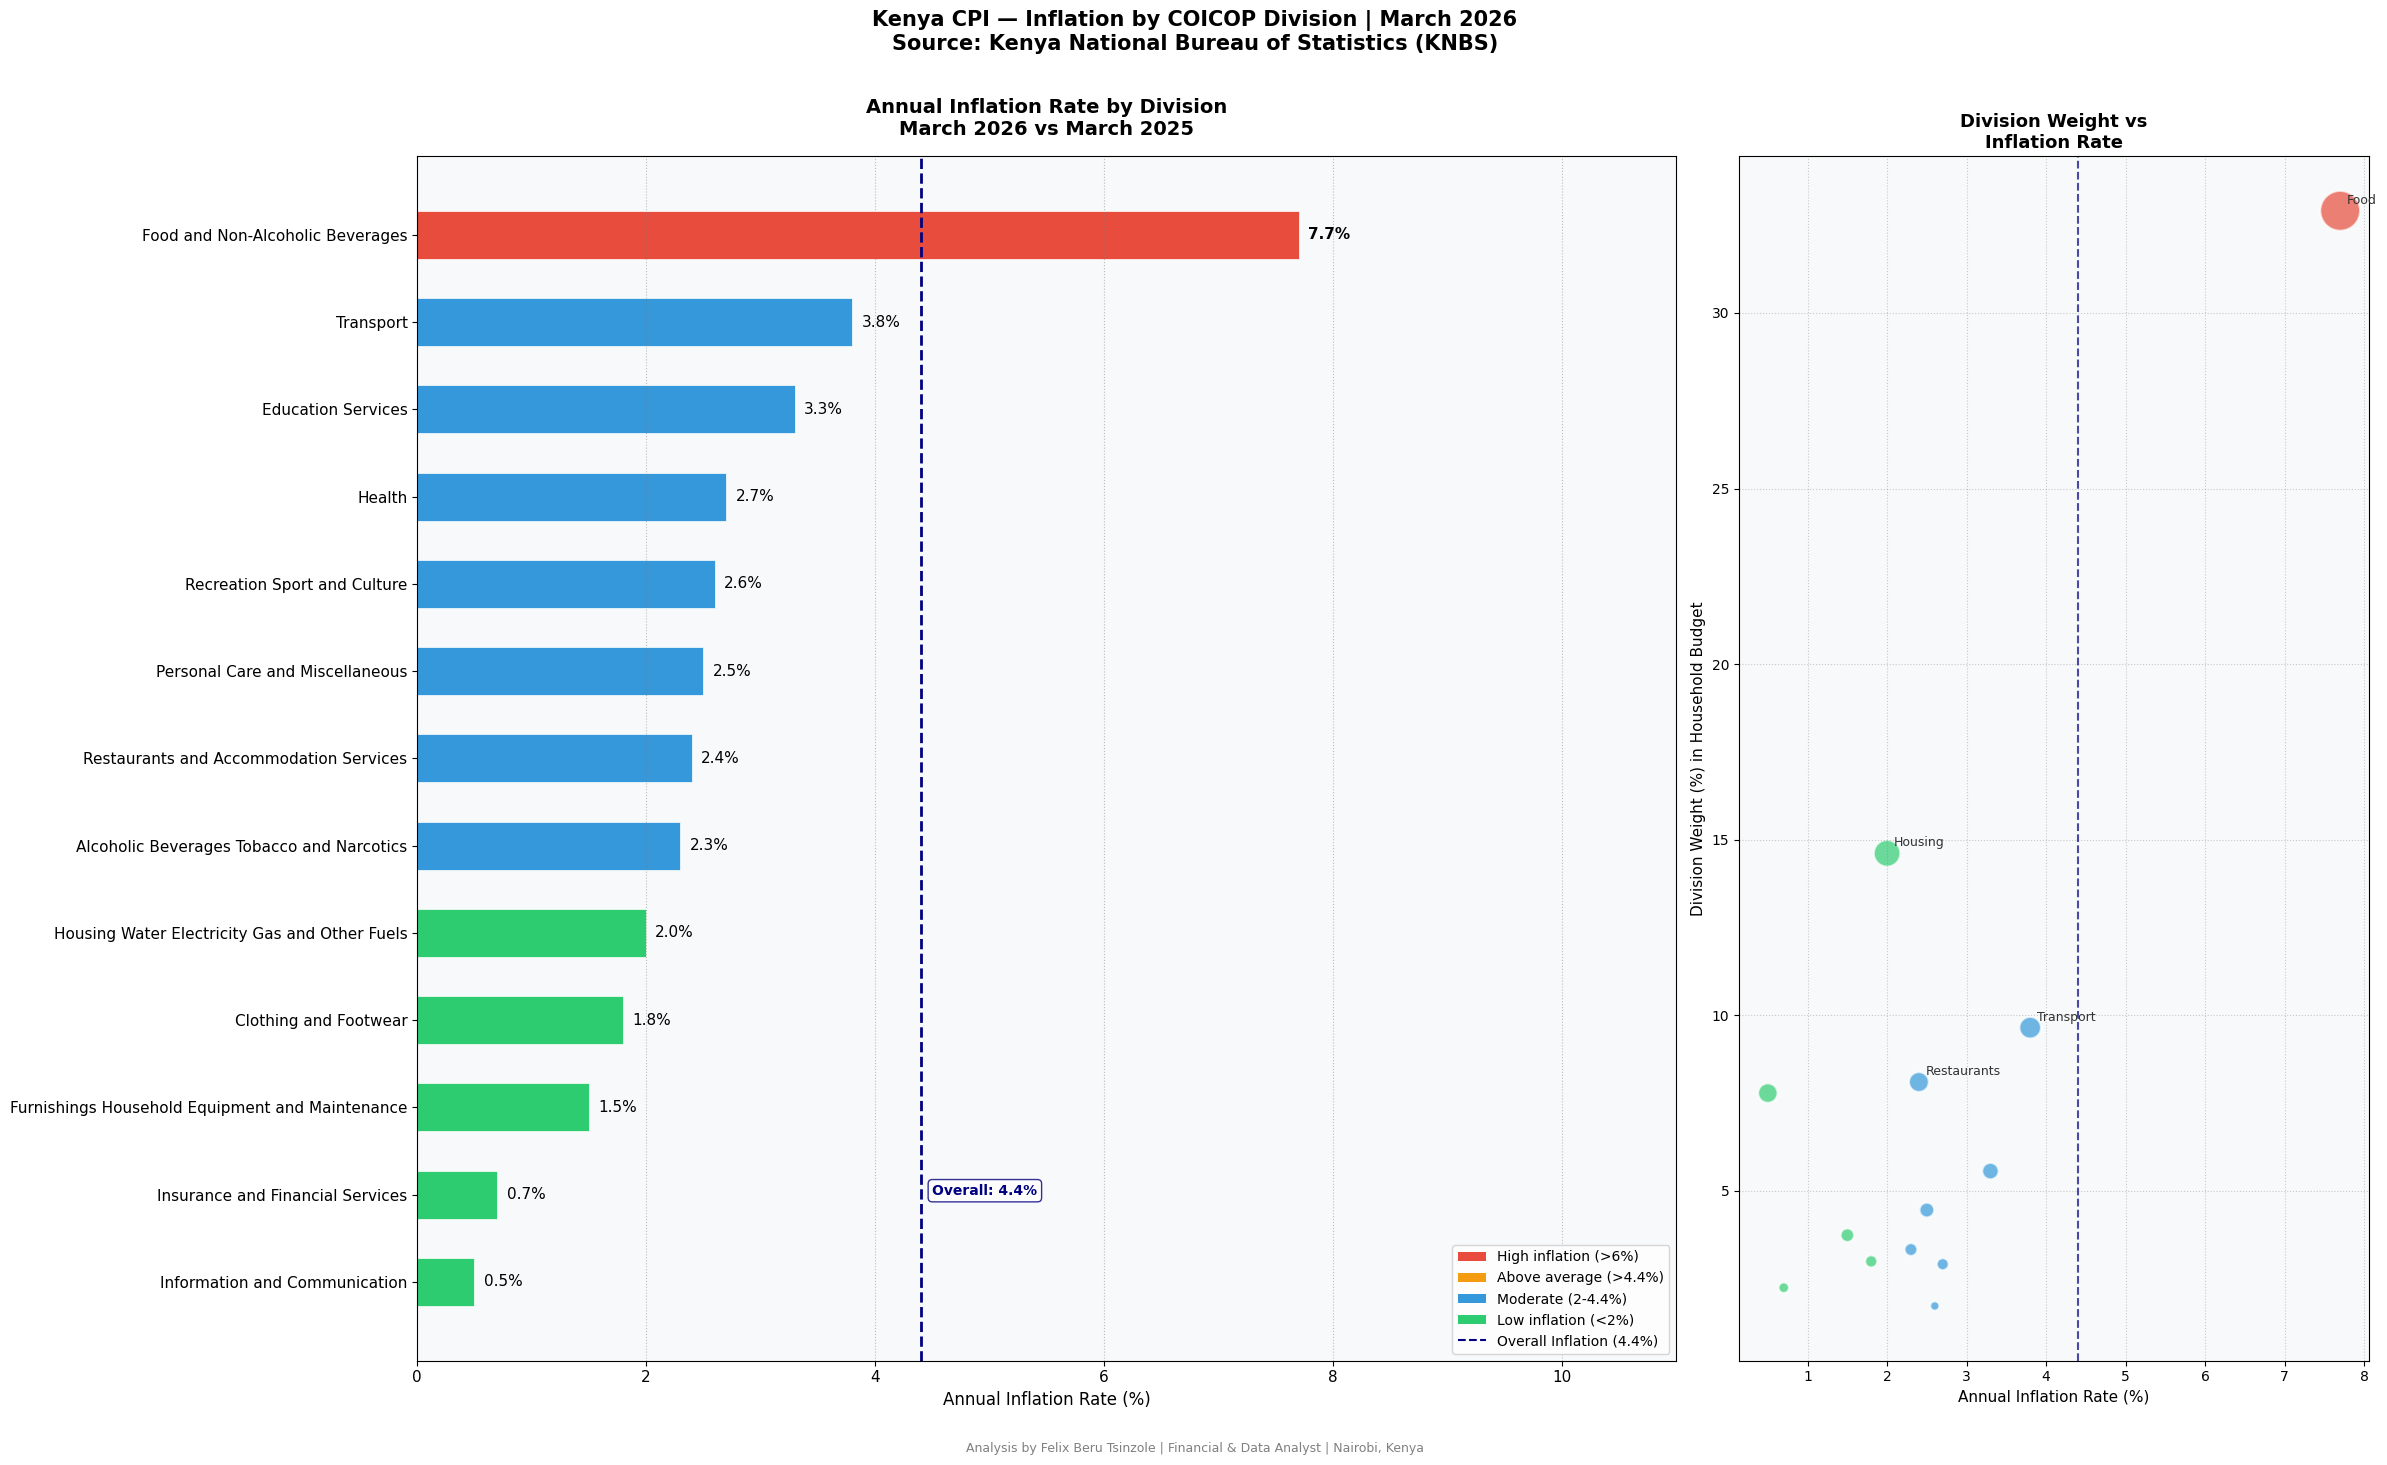


Overall Inflation: 4.4%

Divisions ABOVE overall inflation:
  Food and Non-Alcoholic Beverages              7.7%  (weight: 32.9%)


In [9]:
# ================================================
# SECTION 3 — INFLATION BY DIVISION (IMPROVED)
# ================================================

df_div_sorted = df_divisions.sort_values('Annual_Change', ascending=True)
overall_inflation = 4.4

def div_color(inflation):
    if inflation > 6:
        return '#e74c3c'
    elif inflation > overall_inflation:
        return '#f39c12'
    elif inflation > 2:
        return '#3498db'
    else:
        return '#2ecc71'

colors = [div_color(x) for x in df_div_sorted['Annual_Change']]

fig, axes = plt.subplots(1, 2, figsize=(24, 14),
                          gridspec_kw={'width_ratios': [2, 1]})

# --- Left Chart: Annual Inflation by Division ---
bars = axes[0].barh(
    df_div_sorted['Division'],
    df_div_sorted['Annual_Change'],
    color=colors,
    edgecolor='white',
    linewidth=0.5,
    height=0.55       # ← controls bar thickness — smaller = thinner bars = more space
)

# Value labels — bigger font
for bar, (_, row) in zip(bars, df_div_sorted.iterrows()):
    width = bar.get_width()
    axes[0].text(width + 0.08, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}%', va='center', fontsize=11,
                fontweight='bold' if width > overall_inflation else 'normal')

# Overall inflation benchmark line
axes[0].axvline(x=overall_inflation, color='navy',
                linestyle='--', linewidth=2)
axes[0].text(overall_inflation + 0.1, 1,
            f'Overall: {overall_inflation}%',
            color='navy', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                     edgecolor='navy', alpha=0.8))

axes[0].set_title('Annual Inflation Rate by Division\nMarch 2026 vs March 2025',
                   fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Annual Inflation Rate (%)', fontsize=12)
axes[0].set_xlim(0, 11)
axes[0].set_facecolor('#f8f9fa')

# Bigger y-axis labels
axes[0].tick_params(axis='y', labelsize=11)
axes[0].tick_params(axis='x', labelsize=11)

# Add horizontal gridlines for easier reading
axes[0].grid(axis='x', linestyle=':', alpha=0.5, color='gray')

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#e74c3c', label='High inflation (>6%)'),
    mpatches.Patch(facecolor='#f39c12', label=f'Above average (>{overall_inflation}%)'),
    mpatches.Patch(facecolor='#3498db', label='Moderate (2-4.4%)'),
    mpatches.Patch(facecolor='#2ecc71', label='Low inflation (<2%)'),
    plt.Line2D([0], [0], color='navy', linestyle='--',
               label=f'Overall Inflation ({overall_inflation}%)')
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=10)

# --- Right Chart: Weight vs Inflation Bubble ---
axes[1].scatter(
    df_divisions['Annual_Change'],
    df_divisions['Weight'],
    s=df_divisions['Weight'] * 25,
    c=[div_color(x) for x in df_divisions['Annual_Change']],
    alpha=0.7,
    edgecolors='white',
    linewidth=1.5
)

for _, row in df_divisions.iterrows():
    if row['Weight'] > 8 or row['Annual_Change'] > 6:
        axes[1].annotate(
            row['Division'].split()[0],
            (row['Annual_Change'], row['Weight']),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9,
            color='#333333'
        )

axes[1].axvline(x=overall_inflation, color='navy',
                linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].set_title('Division Weight vs\nInflation Rate',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Annual Inflation Rate (%)', fontsize=11)
axes[1].set_ylabel('Division Weight (%) in Household Budget', fontsize=11)
axes[1].tick_params(axis='both', labelsize=10)
axes[1].set_facecolor('#f8f9fa')
axes[1].grid(linestyle=':', alpha=0.4, color='gray')

# Main title
fig.suptitle('Kenya CPI — Inflation by COICOP Division | March 2026\n'
             'Source: Kenya National Bureau of Statistics (KNBS)',
             fontsize=15, fontweight='bold', y=1.01)

fig.text(0.5, -0.02,
         'Analysis by Felix Beru Tsinzole | Financial & Data Analyst | Nairobi, Kenya',
         ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('/content/kenya_cpi_divisions_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOverall Inflation: {overall_inflation}%")
print(f"\nDivisions ABOVE overall inflation:")
above = df_divisions[df_divisions['Annual_Change'] > overall_inflation]
for _, row in above.sort_values('Annual_Change', ascending=False).iterrows():
    print(f"  {row['Division']:<45} {row['Annual_Change']:.1f}%  (weight: {row['Weight']:.1f}%)")

## Section 4. Commodity Price Movement

### Why Commodity Prices Matter

While division-level inflation shows the big picture,
commodity prices tell the street-level story
what Kenyans actually pay at the market every day.

For businesses and financial analysts, commodity price
movement reveals:

- **Supply chain pressures** — which inputs are getting more expensive
- **Consumer stress points** — which staples are becoming unaffordable
- **Business opportunity** — where price increases are creating demand
  for cheaper alternatives

### Reading This Analysis

We compare prices across three points in time:
- **March 2025** — one year ago (baseline)
- **February 2026** — last month
- **March 2026** — current month

This gives us both:
- **Annual change** — the full year trend
- **Monthly change** — recent momentum

### Key Financial Insight

A commodity showing high annual inflation but negative
monthly change is **cooling down** prices peaked and
are now retreating. A commodity showing both high annual
AND high monthly change is **accelerating** still getting
more expensive. These are very different risk profiles
for a business analyst.

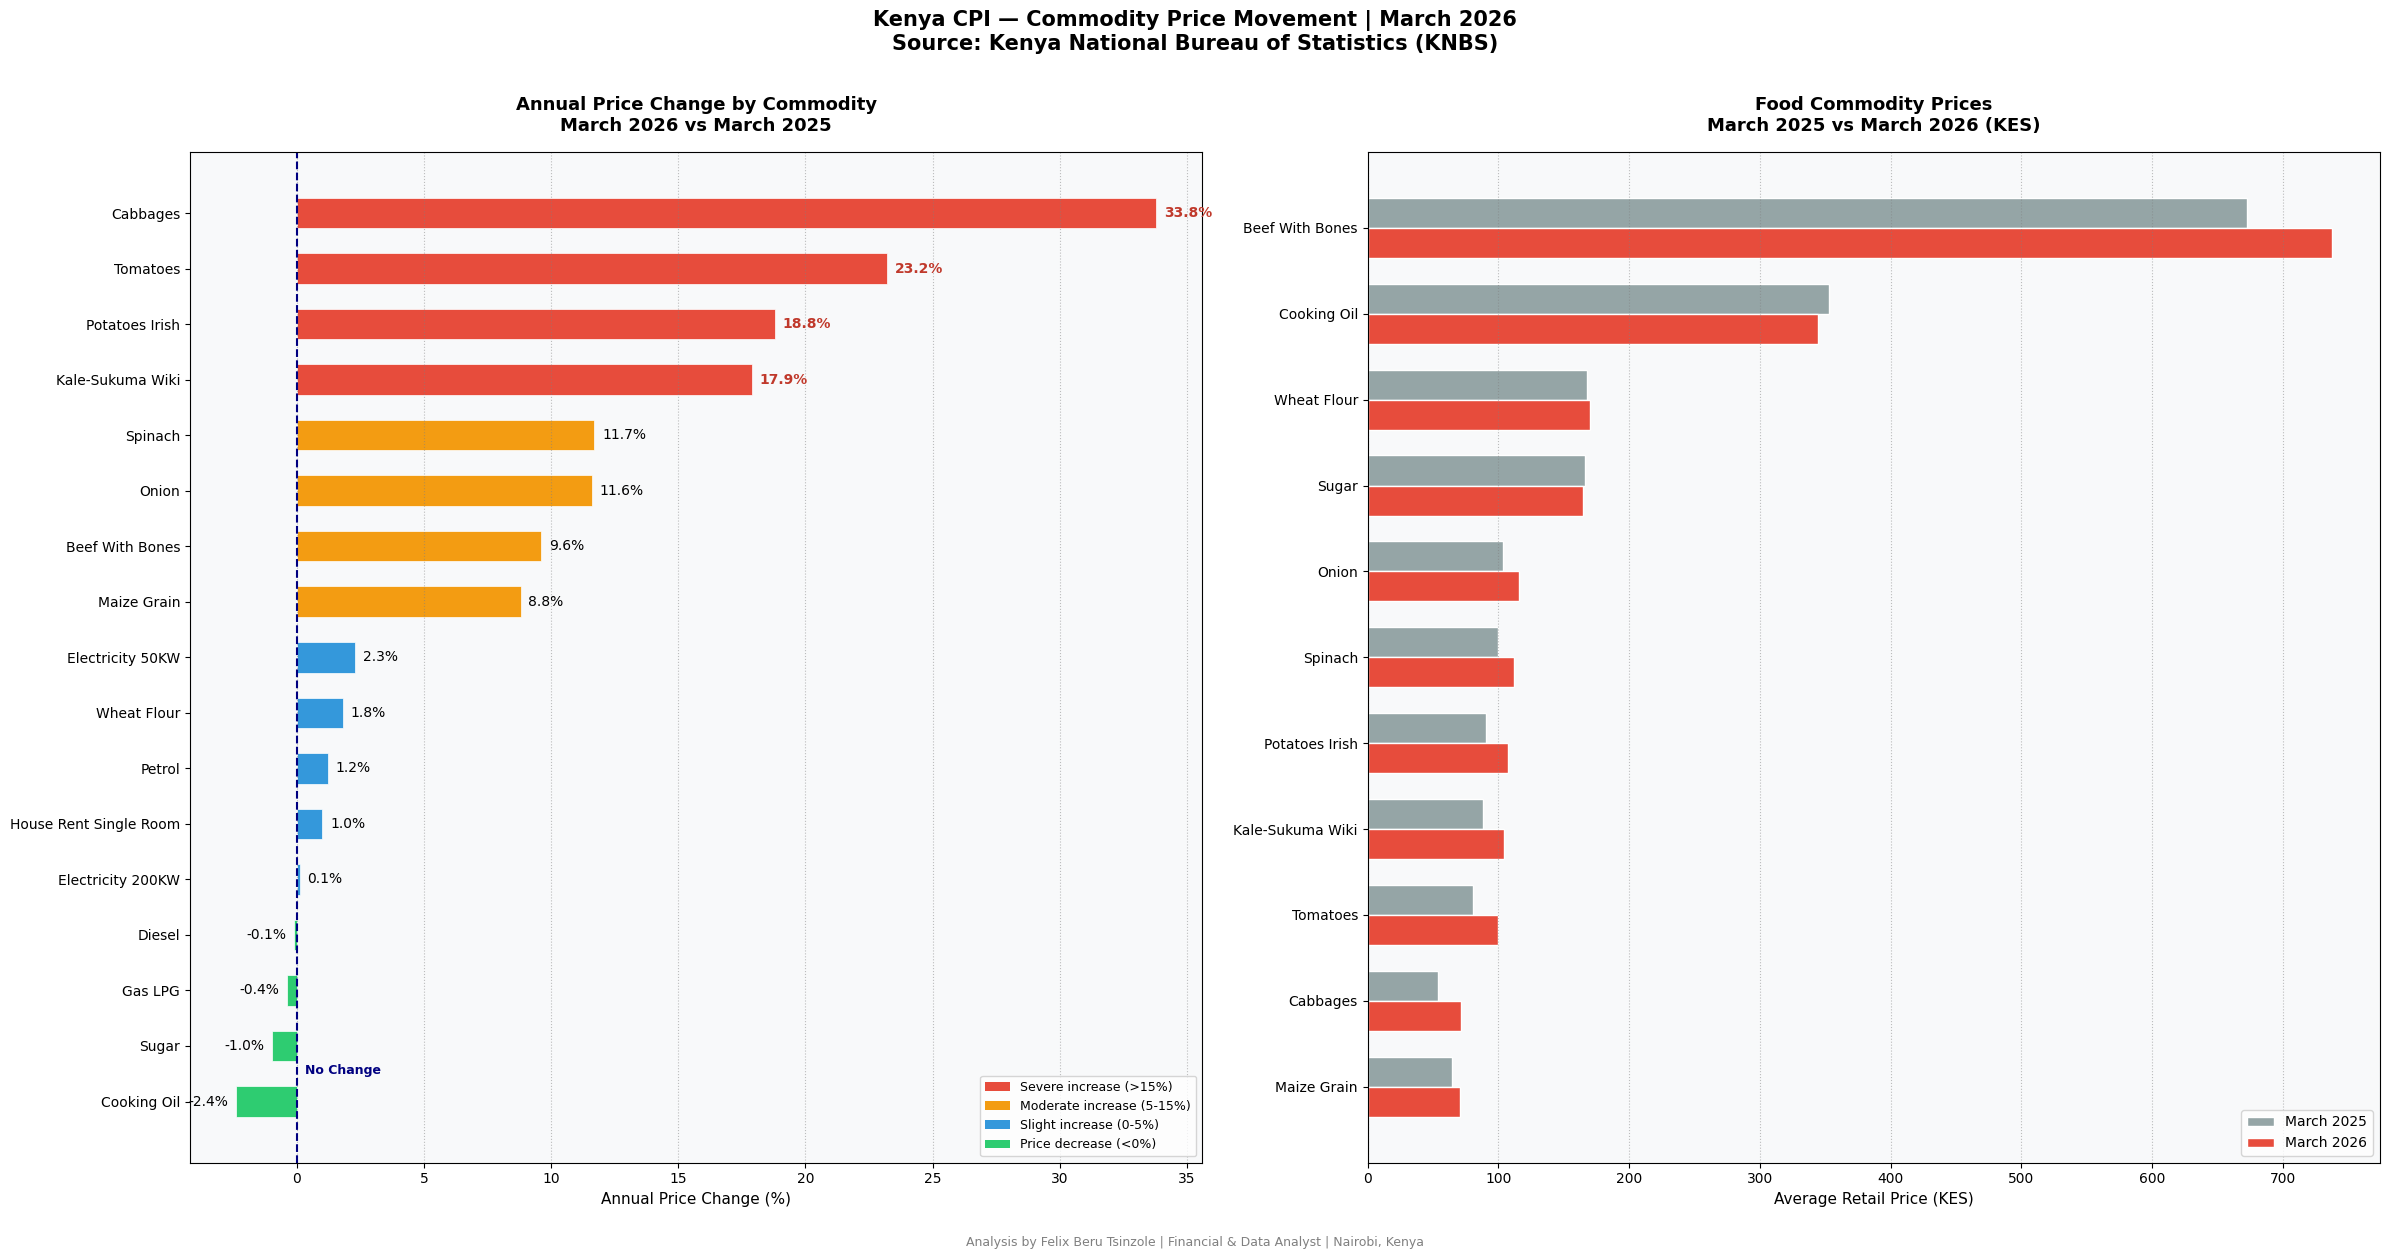


--- Commodity Price Findings ---

Biggest annual price increases:
  Cabbages             KES 53.46 → KES 71.52  (33.8%)
  Tomatoes             KES 80.88 → KES 99.60  (23.2%)
  Potatoes Irish       KES 90.22 → KES 107.16  (18.8%)
  Kale-Sukuma Wiki     KES 88.51 → KES 104.34  (17.9%)
  Spinach              KES 99.92 → KES 111.58  (11.7%)

Commodities with price decreases:
  Sugar                KES 166.08 → KES 164.37  (-1.0%)
  Cooking Oil          KES 353.01 → KES 344.50  (-2.4%)
  Gas LPG              KES 3146.03 → KES 3132.34  (-0.4%)
  Diesel               KES 167.84 → KES 167.72  (-0.1%)


In [10]:
# ================================================
# SECTION 4 — COMMODITY PRICE MOVEMENT
# ================================================

# Sort by annual change for clear storytelling
df_com_sorted = df_commodities.sort_values('Annual_Change', ascending=True)

# Color based on annual price change direction and magnitude
def com_color(change):
    if change > 15:
        return '#e74c3c'    # red — severe price increase
    elif change > 5:
        return '#f39c12'    # amber — moderate increase
    elif change >= 0:
        return '#3498db'    # blue — slight increase
    else:
        return '#2ecc71'    # green — price decrease (good for consumers)

colors_com = [com_color(x) for x in df_com_sorted['Annual_Change']]

fig, axes = plt.subplots(1, 2, figsize=(24, 12),
                          gridspec_kw={'width_ratios': [1, 1]})

# --- Left Chart: Annual Price Change ---
bars1 = axes[0].barh(
    df_com_sorted['Commodity'],
    df_com_sorted['Annual_Change'],
    color=colors_com,
    edgecolor='white',
    linewidth=0.5,
    height=0.55
)

# Value labels
for bar, (_, row) in zip(bars1, df_com_sorted.iterrows()):
    width = bar.get_width()
    x_pos = width + 0.3 if width >= 0 else width - 0.3
    ha = 'left' if width >= 0 else 'right'
    color = '#c0392b' if width > 15 else 'black'
    axes[0].text(x_pos, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}%', va='center', fontsize=10,
                ha=ha, color=color,
                fontweight='bold' if abs(width) > 15 else 'normal')

# Zero line
axes[0].axvline(x=0, color='navy', linewidth=1.5, linestyle='--')
axes[0].text(0.3, 0.5, 'No Change', color='navy',
            fontsize=9, fontweight='bold')

axes[0].set_title('Annual Price Change by Commodity\nMarch 2026 vs March 2025',
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Annual Price Change (%)', fontsize=11)
axes[0].set_facecolor('#f8f9fa')
axes[0].tick_params(axis='y', labelsize=10)
axes[0].tick_params(axis='x', labelsize=10)
axes[0].grid(axis='x', linestyle=':', alpha=0.5, color='gray')

# Legend
legend_elements_com = [
    mpatches.Patch(facecolor='#e74c3c', label='Severe increase (>15%)'),
    mpatches.Patch(facecolor='#f39c12', label='Moderate increase (5-15%)'),
    mpatches.Patch(facecolor='#3498db', label='Slight increase (0-5%)'),
    mpatches.Patch(facecolor='#2ecc71', label='Price decrease (<0%)'),
]
axes[0].legend(handles=legend_elements_com, loc='lower right', fontsize=9)

# --- Right Chart: Price Comparison March 2025 vs March 2026 ---
# Show only food commodities for clarity
food_items = ['Cabbages', 'Maize Grain', 'Spinach', 'Sugar',
              'Kale-Sukuma Wiki', 'Cooking Oil', 'Wheat Flour',
              'Onion', 'Beef With Bones', 'Potatoes Irish', 'Tomatoes']

df_food = df_commodities[df_commodities['Commodity'].isin(food_items)].copy()
df_food = df_food.sort_values('Price_March2026', ascending=True)

x = range(len(df_food))
width = 0.35

bars_2025 = axes[1].barh(
    [i + width/2 for i in x],
    df_food['Price_March2025'],
    height=width,
    color='#95a5a6',
    label='March 2025',
    edgecolor='white'
)

bars_2026 = axes[1].barh(
    [i - width/2 for i in x],
    df_food['Price_March2026'],
    height=width,
    color='#e74c3c',
    label='March 2026',
    edgecolor='white'
)

axes[1].set_yticks(list(x))
axes[1].set_yticklabels(df_food['Commodity'], fontsize=10)
axes[1].set_title('Food Commodity Prices\nMarch 2025 vs March 2026 (KES)',
                   fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Average Retail Price (KES)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_facecolor('#f8f9fa')
axes[1].tick_params(axis='x', labelsize=10)
axes[1].grid(axis='x', linestyle=':', alpha=0.5, color='gray')

# Main title
fig.suptitle('Kenya CPI — Commodity Price Movement | March 2026\n'
             'Source: Kenya National Bureau of Statistics (KNBS)',
             fontsize=15, fontweight='bold', y=1.01)

fig.text(0.5, -0.02,
         'Analysis by Felix Beru Tsinzole | Financial & Data Analyst | Nairobi, Kenya',
         ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('/content/kenya_cpi_commodities_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# Key findings
print("\n--- Commodity Price Findings ---")
print(f"\nBiggest annual price increases:")
top5 = df_commodities.nlargest(5, 'Annual_Change')[['Commodity', 'Price_March2025', 'Price_March2026', 'Annual_Change']]
for _, row in top5.iterrows():
    print(f"  {row['Commodity']:<20} KES {row['Price_March2025']:.2f} → KES {row['Price_March2026']:.2f}  ({row['Annual_Change']:.1f}%)")

print(f"\nCommodities with price decreases:")
decreases = df_commodities[df_commodities['Annual_Change'] < 0][['Commodity', 'Price_March2025', 'Price_March2026', 'Annual_Change']]
for _, row in decreases.iterrows():
    print(f"  {row['Commodity']:<20} KES {row['Price_March2025']:.2f} → KES {row['Price_March2026']:.2f}  ({row['Annual_Change']:.1f}%)")

In [11]:
from google.colab import files
import os

# Download divisions chart
if os.path.exists('/content/kenya_cpi_divisions_chart.png'):
    files.download('/content/kenya_cpi_divisions_chart.png')
    print("✅ Divisions chart downloaded!")
else:
    print("❌ Divisions chart not found — rerun Code Cell 4 first")

# Download commodities chart
if os.path.exists('/content/kenya_cpi_commodities_chart.png'):
    files.download('/content/kenya_cpi_commodities_chart.png')
    print("✅ Commodities chart downloaded!")
else:
    print("❌ Commodities chart not found — rerun Code Cell 5 first")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Divisions chart downloaded!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Commodities chart downloaded!


## Section 5. Core vs Non-Core Inflation Trend

### Understanding Core and Non-Core Inflation

This is one of the most important distinctions in
financial and macroeconomic analysis.

**Core Inflation:**
Measures price changes excluding food and energy
the two most volatile categories. Core inflation reflects
the underlying, structural trend in prices.
It changes slowly and is driven by wages, rents and
services. Central banks watch core inflation closely
because it is harder to reverse.

**Non-Core Inflation:**
Includes food and energy  highly volatile categories
driven by weather, supply chains, global commodity prices
and seasonal factors. Non-core inflation can spike and
fall quickly.

### Why This Matters for Business

A company doing financial planning in Kenya needs to
understand which type of inflation it is facing:

- **High core, low non-core** — structural cost pressure,
  likely to persist. Requires pricing strategy adjustment.
- **Low core, high non-core** — temporary shock,
  likely to ease. May not require immediate pricing action.
- **Both high** — severe environment requiring urgent
  cost management and scenario planning.

### What Kenya's Data Shows

Kenya currently has:
- Core inflation at **2.1%** — low and stable
- Non-core inflation at **10.8%** — high and rising

This tells us Kenya's inflation is being driven almost
entirely by food and energy price shocks
not by structural wage or services inflation.
That is important context for any business analyst.

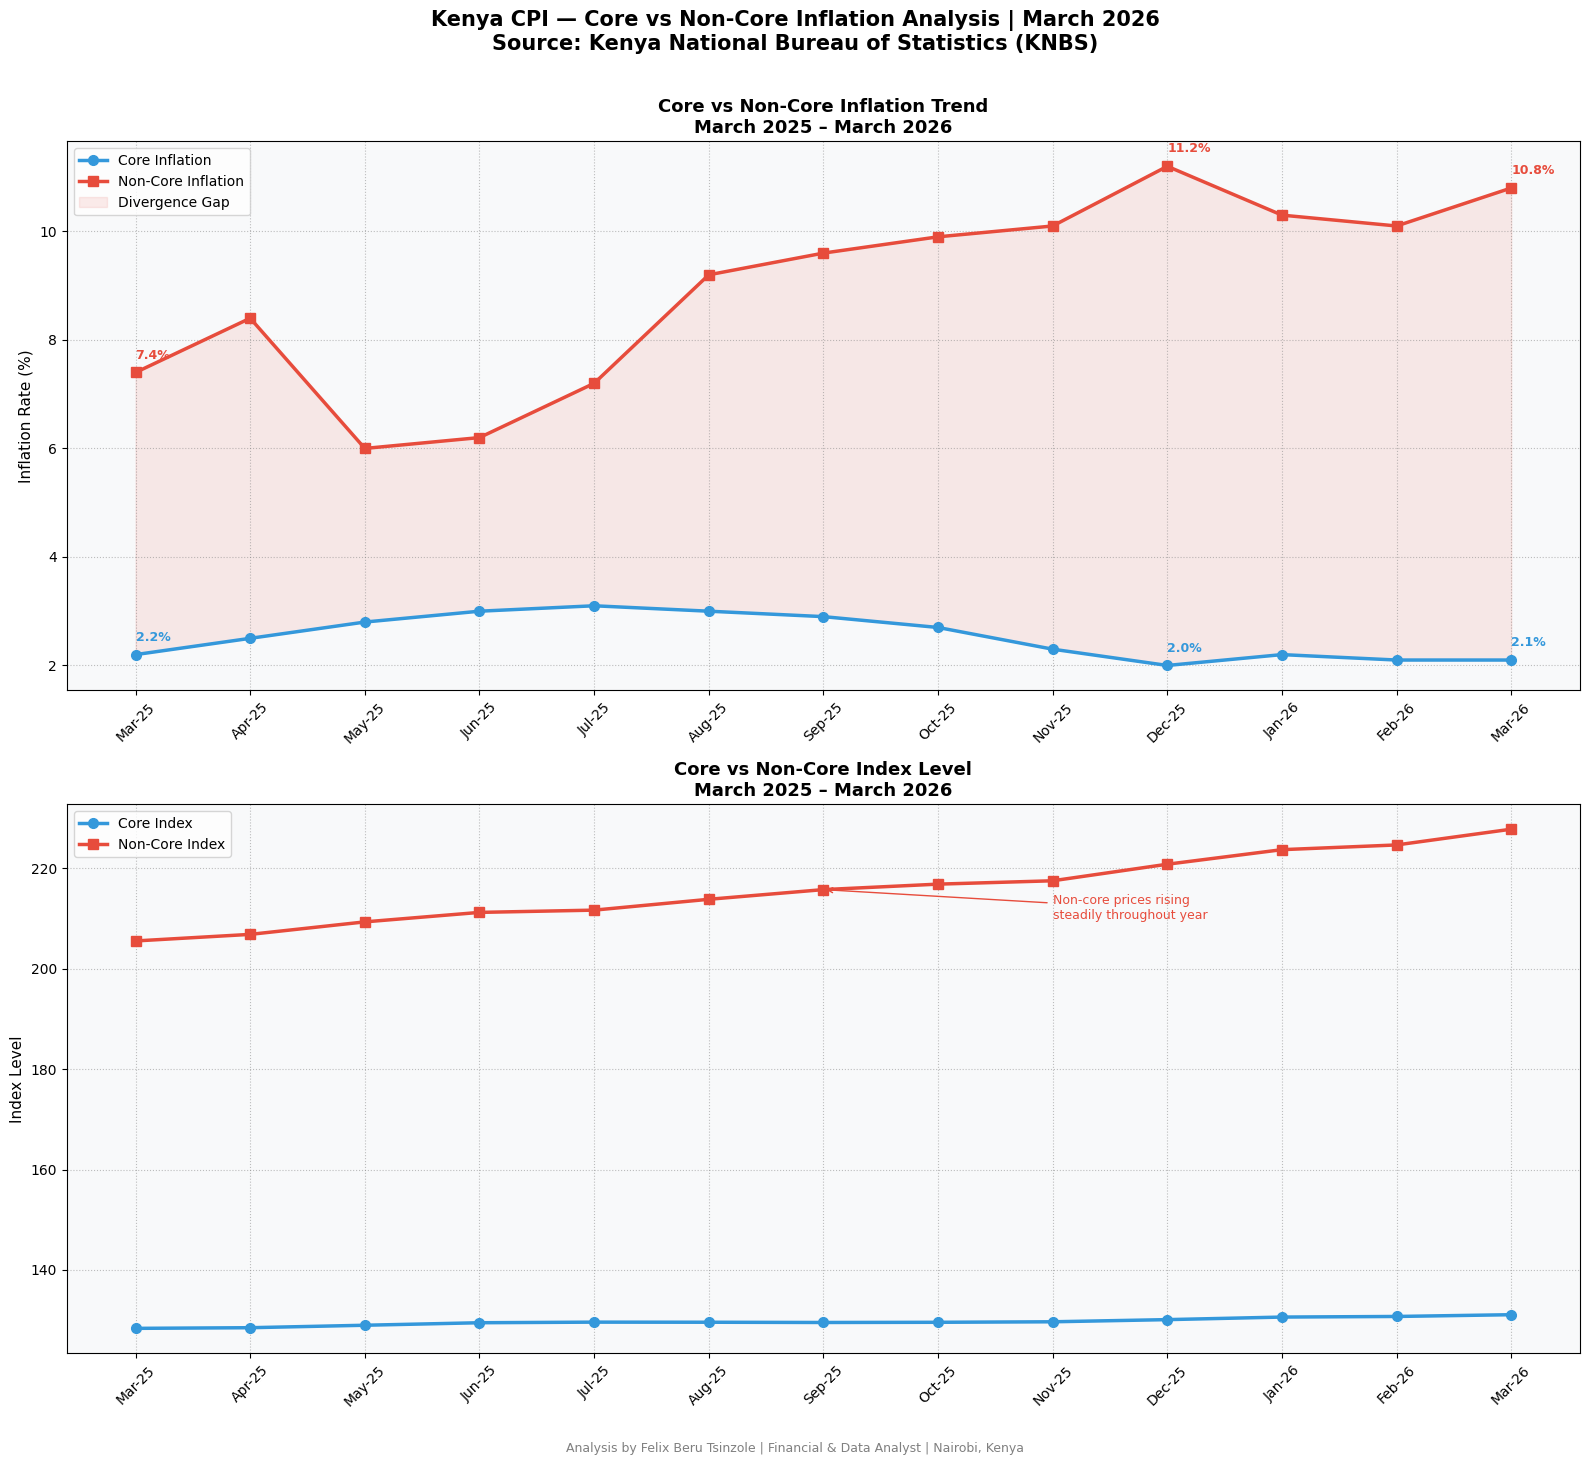

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Core vs Non-Core chart downloaded!

--- Core vs Non-Core Key Findings ---
Core inflation March 2026: 2.1%
Non-Core inflation March 2026: 10.8%
Gap: 8.7 percentage points
Peak non-core inflation: 11.2% in Dec-25
Core inflation range: 2.0% — 3.1%


In [12]:
# ================================================
# SECTION 5 — CORE VS NON-CORE INFLATION TREND
# ================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

periods = df_core['Period']
x = range(len(periods))

# --- Top Chart: Inflation Rate Trend ---
axes[0].plot(x, df_core['Core_Inflation'],
             color='#3498db', linewidth=2.5,
             marker='o', markersize=7,
             label='Core Inflation', zorder=3)

axes[0].plot(x, df_core['NonCore_Inflation'],
             color='#e74c3c', linewidth=2.5,
             marker='s', markersize=7,
             label='Non-Core Inflation', zorder=3)

# Fill between lines to show divergence
axes[0].fill_between(x,
                      df_core['Core_Inflation'],
                      df_core['NonCore_Inflation'],
                      alpha=0.1, color='#e74c3c',
                      label='Divergence Gap')

# Add value labels on key points
for i, (core, noncore) in enumerate(zip(
        df_core['Core_Inflation'], df_core['NonCore_Inflation'])):
    if i == 0 or i == len(df_core) - 1 or i == df_core['NonCore_Inflation'].idxmax():
        axes[0].annotate(f'{core:.1f}%',
                        (i, core),
                        textcoords="offset points",
                        xytext=(0, 10),
                        fontsize=9, color='#3498db',
                        fontweight='bold')
        axes[0].annotate(f'{noncore:.1f}%',
                        (i, noncore),
                        textcoords="offset points",
                        xytext=(0, 10),
                        fontsize=9, color='#e74c3c',
                        fontweight='bold')

axes[0].set_xticks(list(x))
axes[0].set_xticklabels(periods, rotation=45, fontsize=10)
axes[0].set_ylabel('Inflation Rate (%)', fontsize=11)
axes[0].set_title('Core vs Non-Core Inflation Trend\nMarch 2025 – March 2026',
                   fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_facecolor('#f8f9fa')
axes[0].grid(linestyle=':', alpha=0.5, color='gray')
axes[0].tick_params(axis='y', labelsize=10)

# --- Bottom Chart: Index Level Trend ---
axes[1].plot(x, df_core['Core_Index'],
             color='#3498db', linewidth=2.5,
             marker='o', markersize=7,
             label='Core Index')

axes[1].plot(x, df_core['NonCore_Index'],
             color='#e74c3c', linewidth=2.5,
             marker='s', markersize=7,
             label='Non-Core Index')

axes[1].set_xticks(list(x))
axes[1].set_xticklabels(periods, rotation=45, fontsize=10)
axes[1].set_ylabel('Index Level', fontsize=11)
axes[1].set_title('Core vs Non-Core Index Level\nMarch 2025 – March 2026',
                   fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_facecolor('#f8f9fa')
axes[1].grid(linestyle=':', alpha=0.5, color='gray')
axes[1].tick_params(axis='y', labelsize=10)

# Annotations
axes[1].annotate('Non-core prices rising\nsteadily throughout year',
                xy=(6, df_core['NonCore_Index'].iloc[6]),
                xytext=(8, 210),
                fontsize=9, color='#e74c3c',
                arrowprops=dict(arrowstyle='->', color='#e74c3c'))

# Main title
fig.suptitle('Kenya CPI — Core vs Non-Core Inflation Analysis | March 2026\n'
             'Source: Kenya National Bureau of Statistics (KNBS)',
             fontsize=15, fontweight='bold', y=1.01)

fig.text(0.5, -0.02,
         'Analysis by Felix Beru Tsinzole | Financial & Data Analyst | Nairobi, Kenya',
         ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('/content/kenya_cpi_core_noncore_chart.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('/content/kenya_cpi_core_noncore_chart.png')
print("✅ Core vs Non-Core chart downloaded!")

# Key metrics
print("\n--- Core vs Non-Core Key Findings ---")
print(f"Core inflation March 2026: {df_core['Core_Inflation'].iloc[-1]}%")
print(f"Non-Core inflation March 2026: {df_core['NonCore_Inflation'].iloc[-1]}%")
print(f"Gap: {df_core['NonCore_Inflation'].iloc[-1] - df_core['Core_Inflation'].iloc[-1]:.1f} percentage points")
print(f"Peak non-core inflation: {df_core['NonCore_Inflation'].max()}% in {df_core.loc[df_core['NonCore_Inflation'].idxmax(), 'Period']}")
print(f"Core inflation range: {df_core['Core_Inflation'].min()}% — {df_core['Core_Inflation'].max()}%")

## Section 6. Weighted Inflation Impact Analysis

### What Is Weighted Impact Analysis?

The overall inflation rate of 4.4% is a weighted average
but not every division contributes equally to that figure.

A division with 32.9% weight and 7.7% inflation contributes
far more to the overall rate than a division with 2% weight
and 7.7% inflation even though the inflation rate is identical.

**Weighted Contribution Formula:**
Weighted Contribution = (Division Weight / 100) × Division Inflation Rate

This tells us exactly how many percentage points each division
is adding to Kenya's overall 4.4% inflation rate.

### Why This Matters for Financial Analysts

Understanding weighted contribution allows analysts to:

- **Prioritise** — focus on the divisions driving inflation,
  not just the ones with high rates
- **Forecast** — if food prices ease, by how much will
  overall inflation fall?
- **Advise** — tell clients and management which cost
  categories to watch most closely

This is the kind of analysis that separates a data analyst
from a financial analyst. Anyone can show a bar chart
of inflation rates. A financial analyst shows the
contribution and what it means for the business.

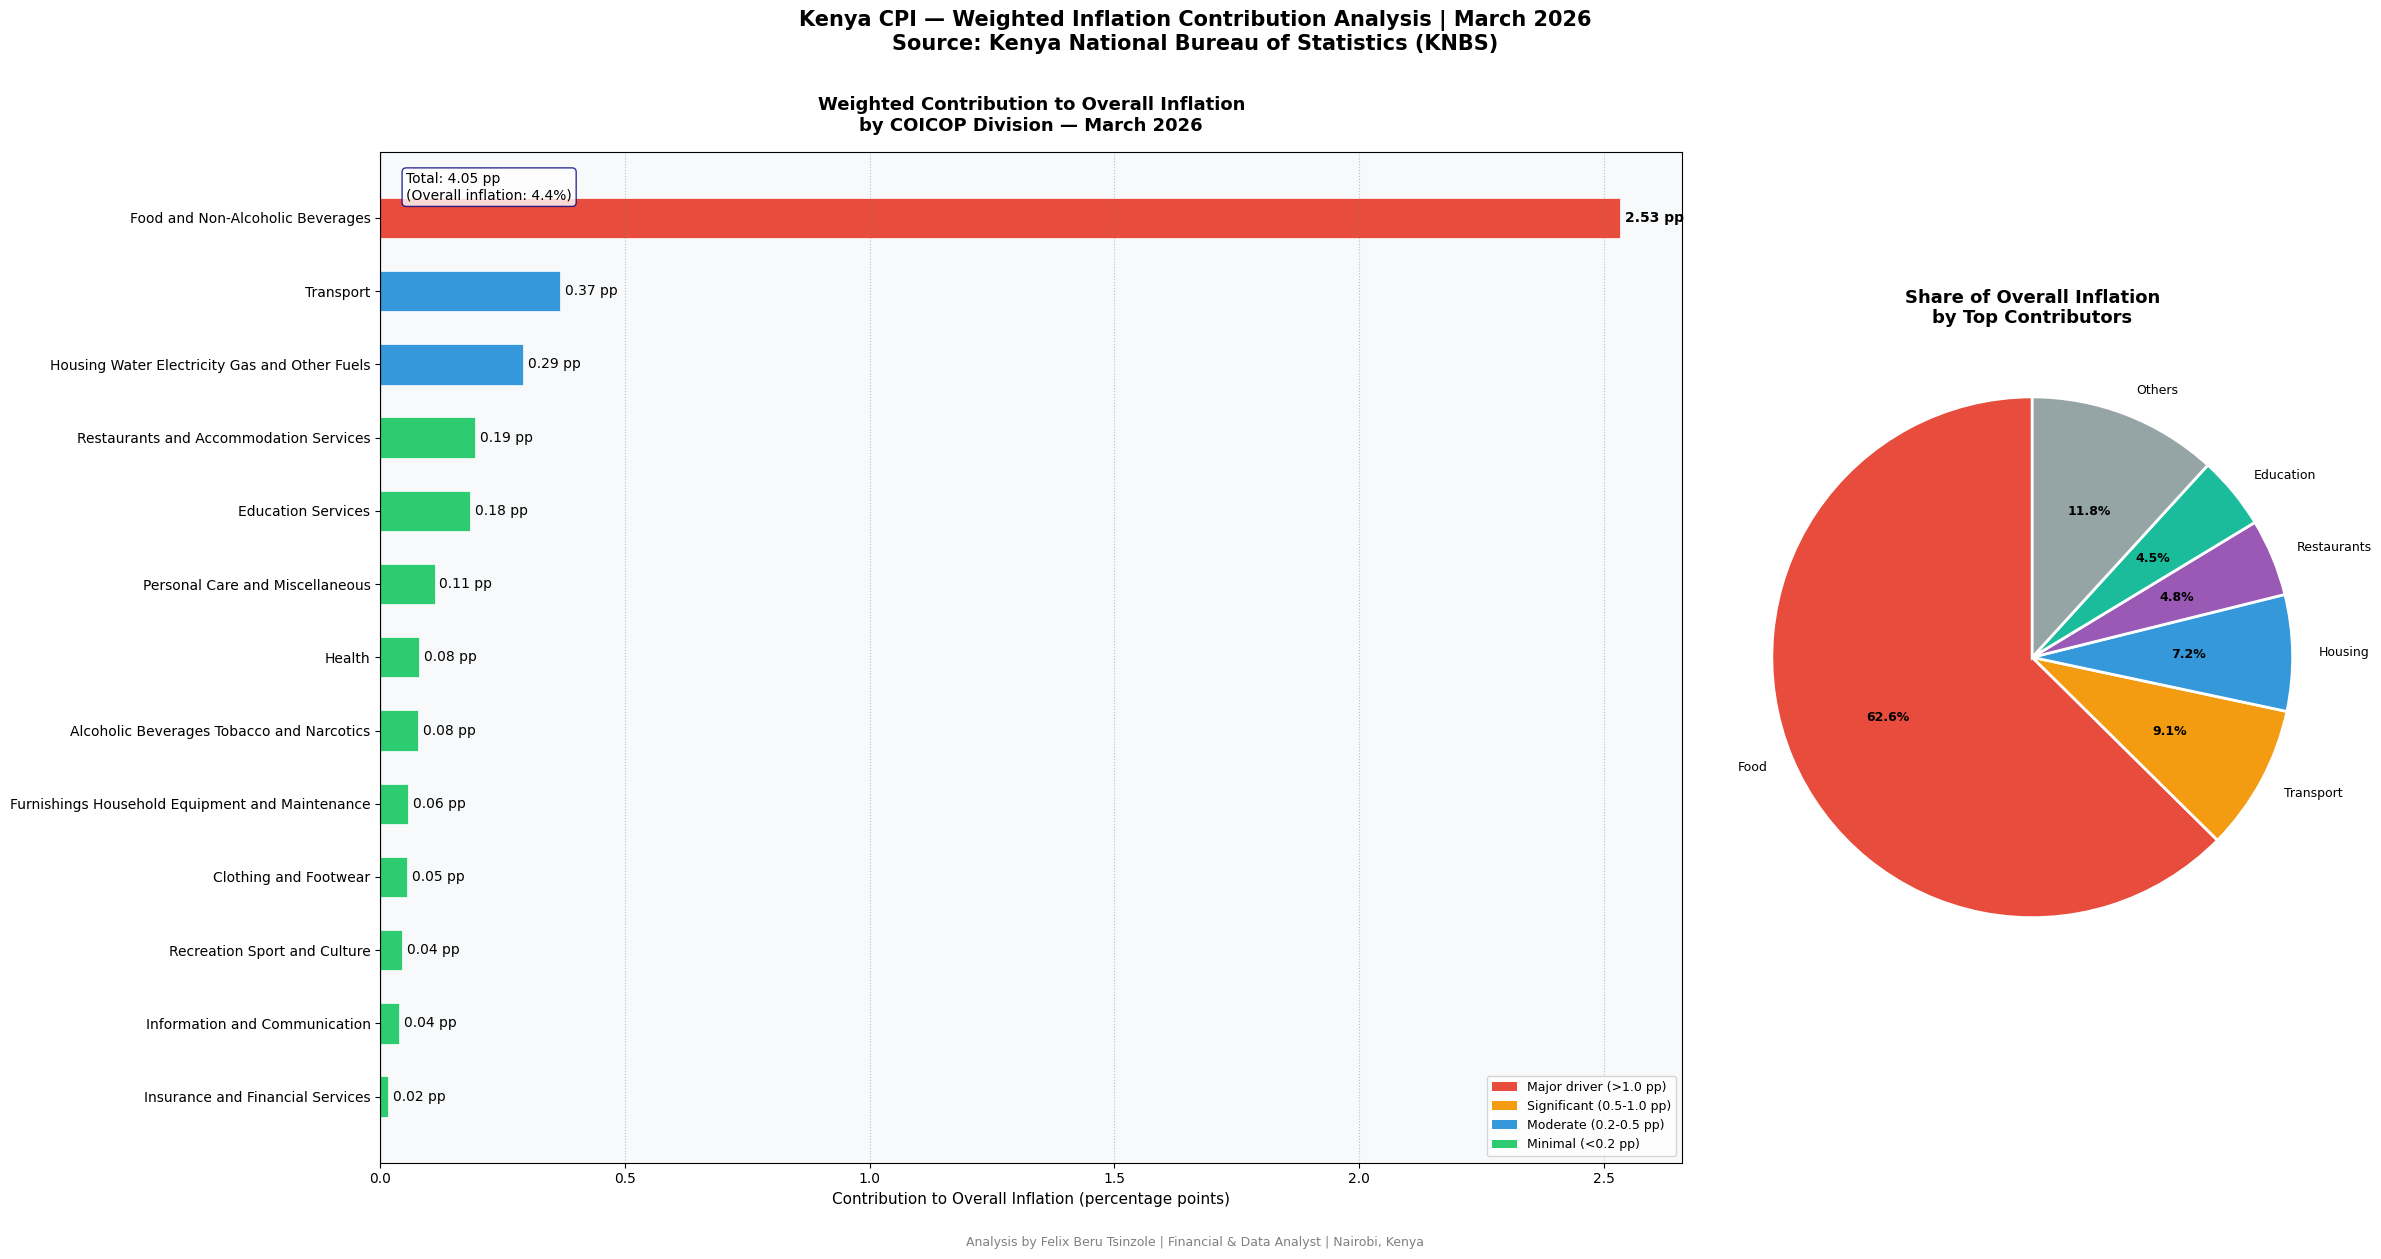

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Weighted impact chart downloaded!

--- Weighted Contribution Findings ---
Total weighted contribution: 4.05 percentage points
Overall reported inflation: 4.4%

Top 5 contributors to inflation:
  Food and Non-Alcoholic Beverages              2.534 pp  (62.6% of total)
  Transport                                     0.367 pp  (9.1% of total)
  Housing Water Electricity Gas and Other Fuels 0.292 pp  (7.2% of total)
  Restaurants and Accommodation Services        0.194 pp  (4.8% of total)
  Education Services                            0.184 pp  (4.5% of total)

Food contribution alone: 2.534 pp


In [13]:
# ================================================
# SECTION 6 — WEIGHTED INFLATION IMPACT ANALYSIS
# ================================================

# Calculate weighted contribution of each division
df_divisions['Weighted_Contribution'] = (
    df_divisions['Weight'] / 100 * df_divisions['Annual_Change']
).round(3)

# Sort by weighted contribution
df_weighted = df_divisions.sort_values('Weighted_Contribution', ascending=True)

# Total weighted contribution should approximate overall inflation
total_contribution = df_divisions['Weighted_Contribution'].sum()

# Color based on contribution size
def contrib_color(contribution):
    if contribution > 1.0:
        return '#e74c3c'    # red — major driver
    elif contribution > 0.5:
        return '#f39c12'    # amber — significant contributor
    elif contribution > 0.2:
        return '#3498db'    # blue — moderate
    else:
        return '#2ecc71'    # green — minimal impact

colors_weighted = [contrib_color(x) for x in df_weighted['Weighted_Contribution']]

fig, axes = plt.subplots(1, 2, figsize=(24, 12),
                          gridspec_kw={'width_ratios': [2, 1]})

# --- Left Chart: Weighted Contribution Bar Chart ---
bars = axes[0].barh(
    df_weighted['Division'],
    df_weighted['Weighted_Contribution'],
    color=colors_weighted,
    edgecolor='white',
    linewidth=0.5,
    height=0.55
)

# Value labels
for bar, (_, row) in zip(bars, df_weighted.iterrows()):
    width = bar.get_width()
    axes[0].text(width + 0.01, bar.get_y() + bar.get_height()/2,
                f'{width:.2f} pp', va='center', fontsize=10,
                fontweight='bold' if width > 1.0 else 'normal')

# Total contribution line
axes[0].axvline(x=0, color='navy', linewidth=1, linestyle='-', alpha=0.3)

axes[0].set_title('Weighted Contribution to Overall Inflation\nby COICOP Division — March 2026',
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Contribution to Overall Inflation (percentage points)',
                    fontsize=11)
axes[0].set_facecolor('#f8f9fa')
axes[0].tick_params(axis='y', labelsize=10)
axes[0].tick_params(axis='x', labelsize=10)
axes[0].grid(axis='x', linestyle=':', alpha=0.5, color='gray')

# Annotation
axes[0].text(0.02, 0.98,
            f'Total: {total_contribution:.2f} pp\n(Overall inflation: 4.4%)',
            transform=axes[0].transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white',
                     edgecolor='navy', alpha=0.8))

# Legend
legend_elements_w = [
    mpatches.Patch(facecolor='#e74c3c', label='Major driver (>1.0 pp)'),
    mpatches.Patch(facecolor='#f39c12', label='Significant (0.5-1.0 pp)'),
    mpatches.Patch(facecolor='#3498db', label='Moderate (0.2-0.5 pp)'),
    mpatches.Patch(facecolor='#2ecc71', label='Minimal (<0.2 pp)'),
]
axes[0].legend(handles=legend_elements_w, loc='lower right', fontsize=9)

# --- Right Chart: Pie Chart of Contribution ---
# Top 5 contributors and Others
top5_contrib = df_divisions.nlargest(5, 'Weighted_Contribution')
others_contrib = total_contribution - top5_contrib['Weighted_Contribution'].sum()

pie_labels = list(top5_contrib['Division'].str.split().str[0]) + ['Others']
pie_values = list(top5_contrib['Weighted_Contribution']) + [others_contrib]
pie_colors = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#1abc9c', '#95a5a6']

wedges, texts, autotexts = axes[1].pie(
    pie_values,
    labels=pie_labels,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 9},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

axes[1].set_title('Share of Overall Inflation\nby Top Contributors',
                   fontsize=13, fontweight='bold')

# Main title
fig.suptitle('Kenya CPI — Weighted Inflation Contribution Analysis | March 2026\n'
             'Source: Kenya National Bureau of Statistics (KNBS)',
             fontsize=15, fontweight='bold', y=1.01)

fig.text(0.5, -0.02,
         'Analysis by Felix Beru Tsinzole | Financial & Data Analyst | Nairobi, Kenya',
         ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('/content/kenya_cpi_weighted_chart.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('/content/kenya_cpi_weighted_chart.png')
print("✅ Weighted impact chart downloaded!")

# Key findings
print("\n--- Weighted Contribution Findings ---")
print(f"Total weighted contribution: {total_contribution:.2f} percentage points")
print(f"Overall reported inflation: 4.4%")
print(f"\nTop 5 contributors to inflation:")
top5 = df_divisions.nlargest(5, 'Weighted_Contribution')
for _, row in top5.iterrows():
    print(f"  {row['Division']:<45} {row['Weighted_Contribution']:.3f} pp  "
          f"({row['Weighted_Contribution']/total_contribution*100:.1f}% of total)")
print(f"\nFood contribution alone: "
      f"{df_divisions[df_divisions['Division'].str.contains('Food')]['Weighted_Contribution'].values[0]:.3f} pp")

## Section 7. Executive Summary & Business Implications

### Key Findings at a Glance

This analysis of Kenya's CPI data for March 2025 to March 2026
reveals four critical insights:

---

**Finding 1 - Food is driving almost everything**
Food and Non-Alcoholic Beverages contributes **2.53 percentage points**
to Kenya's overall 4.4% inflation rate accounting for **62.6%**
of total inflation despite being just one of 13 divisions.
Tomatoes (+23.2%), Cabbages (+33.8%) and Kale (+17.9%) are
the sharpest risers. This is the dominant story in Kenya's
current inflation environment.

---

**Finding 2 - Core inflation is stable and low**
Core inflation which excludes food and energy has remained
remarkably stable between 2.0% and 3.1% throughout the year.
This tells us Kenya does not have a structural inflation problem.
The economy's underlying cost of services, wages and rents
is not spiralling. The inflation crisis is entirely driven
by food and energy price shocks which can ease faster
than structural inflation.

---

**Finding 3 - Non-core inflation peaked and is slowly easing**
Non-core inflation peaked at 11.2% in December 2025 and has
slightly eased to 10.8% in March 2026. The gap between core
and non-core inflation stands at 8.7 percentage points
an unusually wide divergence that signals food and energy
supply pressures rather than broad economic overheating.

---

**Finding 4 - Energy costs are a secondary but persistent pressure**
Housing, Water, Electricity and Gas contributes 0.29 percentage
points to overall inflation making it the third largest
contributor. Electricity costs rose 2.5% annually for small
consumers (50KW). Petrol remained flat at 1.2% annual increase.
LPG gas prices actually fell slightly down 0.4% annually.

---

### Business Implications

**For companies serving rural Kenyan households:**

The data paints a clear picture of a consumer under pressure.
Food prices are rising nearly twice as fast as overall inflation.
Non-core inflation at 10.8% means the cost of basic household
necessities is rising sharply. Disposable income the money
available after food and energy is being squeezed from both ends.

For businesses operating a loan-to-own model in rural Kenya,
this has direct implications:

1. **Collections risk** — rising food costs reduce household
   disposable income available for loan repayments

2. **Value proposition strengthens** — as kerosene and energy
   costs rise, solar alternatives become relatively more
   attractive and affordable

3. **Pricing sensitivity** — rural consumers are more price
   sensitive than ever. Product pricing and repayment
   structures must account for food inflation cycles

4. **Opportunity in adversity** — counties where food inflation
   is highest and energy access is lowest represent the
   strongest market opportunity for affordable clean energy

---

### Analyst Note on Methodology

This analysis uses KNBS published CPI data for March 2026.
Weighted contributions were calculated using the formula:
**Weighted Contribution = (Division Weight / 100) × Annual Inflation Rate**

Total weighted contribution of 4.05 percentage points compares
to the reported overall inflation of 4.4%, a 0.35 pp rounding
difference attributable to index calculation methodology
used by KNBS in their official computation.

All prices are in Kenya Shillings (KES).
Data covers the period March 2025 to March 2026.

In [14]:
# ================================================
# SECTION 7 — EXECUTIVE SUMMARY STATISTICS
# ================================================

print("=" * 65)
print("  KENYA CPI INFLATION ANALYSIS — EXECUTIVE SUMMARY")
print("  Period: March 2025 – March 2026")
print("  Source: KNBS Consumer Price Index Report March 2026")
print("  Analyst: Felix Beru Tsinzole")
print("=" * 65)

print("\n📊 OVERALL INFLATION")
print(f"  Overall inflation rate (March 2026):     4.4%")
print(f"  Monthly change (March/February 2026):    0.5%")

print("\n📊 CORE VS NON-CORE")
print(f"  Core inflation (March 2026):             {df_core['Core_Inflation'].iloc[-1]}%")
print(f"  Non-core inflation (March 2026):         {df_core['NonCore_Inflation'].iloc[-1]}%")
print(f"  Divergence gap:                          {df_core['NonCore_Inflation'].iloc[-1] - df_core['Core_Inflation'].iloc[-1]:.1f} pp")
print(f"  Peak non-core inflation:                 {df_core['NonCore_Inflation'].max()}% ({df_core.loc[df_core['NonCore_Inflation'].idxmax(), 'Period']})")

print("\n📊 TOP INFLATION DRIVERS BY DIVISION")
top3_div = df_divisions.nlargest(3, 'Annual_Change')
for _, row in top3_div.iterrows():
    print(f"  {row['Division']:<45} {row['Annual_Change']:.1f}%")

print("\n📊 WEIGHTED CONTRIBUTION")
food_contrib = df_divisions[df_divisions['Division'].str.contains('Food')]['Weighted_Contribution'].values[0]
print(f"  Food contribution to overall inflation:  {food_contrib:.3f} pp ({food_contrib/total_contribution*100:.1f}%)")
print(f"  Total weighted contribution:             {total_contribution:.2f} pp")

print("\n📊 COMMODITY PRICE HIGHLIGHTS")
top3_com = df_commodities.nlargest(3, 'Annual_Change')
bottom3_com = df_commodities.nsmallest(3, 'Annual_Change')
print("  Biggest price increases (annual):")
for _, row in top3_com.iterrows():
    print(f"    {row['Commodity']:<20} KES {row['Price_March2025']:.2f} → KES {row['Price_March2026']:.2f}  (+{row['Annual_Change']:.1f}%)")
print("  Price decreases (annual):")
for _, row in bottom3_com.iterrows():
    print(f"    {row['Commodity']:<20} KES {row['Price_March2025']:.2f} → KES {row['Price_March2026']:.2f}  ({row['Annual_Change']:.1f}%)")

print("\n📊 BUSINESS IMPLICATION FOR RURAL KENYA")
print(f"  Food share of household budget:          32.9%")
print(f"  Food annual inflation:                   7.7%")
print(f"  Effective food cost burden increase:     {0.329 * 7.7:.2f}% of total household budget")
print(f"  Energy (Housing/Gas) contribution:       0.29 pp to overall inflation")

print("\n" + "=" * 65)
print("✅ ANALYSIS COMPLETE")
print("=" * 65)

  KENYA CPI INFLATION ANALYSIS — EXECUTIVE SUMMARY
  Period: March 2025 – March 2026
  Source: KNBS Consumer Price Index Report March 2026
  Analyst: Felix Beru Tsinzole

📊 OVERALL INFLATION
  Overall inflation rate (March 2026):     4.4%
  Monthly change (March/February 2026):    0.5%

📊 CORE VS NON-CORE
  Core inflation (March 2026):             2.1%
  Non-core inflation (March 2026):         10.8%
  Divergence gap:                          8.7 pp
  Peak non-core inflation:                 11.2% (Dec-25)

📊 TOP INFLATION DRIVERS BY DIVISION
  Food and Non-Alcoholic Beverages              7.7%
  Transport                                     3.8%
  Education Services                            3.3%

📊 WEIGHTED CONTRIBUTION
  Food contribution to overall inflation:  2.534 pp (62.6%)
  Total weighted contribution:             4.05 pp

📊 COMMODITY PRICE HIGHLIGHTS
  Biggest price increases (annual):
    Cabbages             KES 53.46 → KES 71.52  (+33.8%)
    Tomatoes             KES 80.8

## Closing Note

This analysis was built entirely using Python, Pandas and Matplotlib
on publicly available data from the Kenya National Bureau of Statistics.

The goal was not just to visualize numbers but to extract the
financial and business meaning behind Kenya's inflation data
and communicate it in a way that supports real decisions.

**Key tools used:**
- Python 3 — data processing and analysis
- Pandas — data loading, cleaning and manipulation
- Matplotlib — professional chart creation
- Google Colab — cloud-based development environment
- GitHub — version control and portfolio publishing

**Data source:**
Kenya National Bureau of Statistics (KNBS)
Consumer Price Index and Inflation Report March 2026

---

*Felix Beru Tsinzole | Financial & Data Analyst | Nairobi, Kenya*
*github.com/FelixBeruTheAnalyst*

In [19]:
import os
from google.colab import files
import matplotlib
matplotlib.use('Agg')

# Check which charts exist
charts = [
    '/content/kenya_cpi_divisions_chart.png',
    '/content/kenya_cpi_commodities_chart.png',
    '/content/kenya_cpi_core_noncore_chart.png',
    '/content/kenya_cpi_weighted_chart.png'
]

print("Checking saved charts:")
for chart in charts:
    if os.path.exists(chart):
        print(f"✅ Found: {chart}")
    else:
        print(f"❌ Missing: {chart}")

Checking saved charts:
✅ Found: /content/kenya_cpi_divisions_chart.png
✅ Found: /content/kenya_cpi_commodities_chart.png
✅ Found: /content/kenya_cpi_core_noncore_chart.png
✅ Found: /content/kenya_cpi_weighted_chart.png


In [21]:
from google.colab import files

charts = [
    '/content/kenya_cpi_divisions_chart.png',
    '/content/kenya_cpi_commodities_chart.png',
    '/content/kenya_cpi_core_noncore_chart.png',
    '/content/kenya_cpi_weighted_chart.png'
]

for chart in charts:
    files.download(chart)
    print(f"✅ Downloaded: {chart.split('/')[-1]}")

print("\n✅ All charts downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: kenya_cpi_divisions_chart.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: kenya_cpi_core_noncore_chart.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: kenya_cpi_weighted_chart.png

✅ All charts downloaded!
